_Connecting to Python 3.10.9..._

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('finesse_dataset.csv')

In [ ]:
user_data = df.groupby('user_id').agg(
    total_spent=('amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    monthly_budget=('monthly_budget', 'first') # Diambil data pertama karena budget bulanan tetap
).reset_index()

# Membuat fitur cerdas baru: Seberapa boros mereka terhadap budgetnya?
user_data['budget_utilization'] = user_data['total_spent'] / user_data['monthly_budget']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

df = pd.read_csv('finesse_dataset.csv')

In [ ]:
user_data = df.groupby('user_id').agg(
    total_spent=('amount', 'sum'),
    transaction_count=('transaction_id', 'count'),
    monthly_budget=('monthly_budget', 'first') # Diambil data pertama karena budget bulanan tetap
).reset_index()

# Membuat fitur cerdas baru: Seberapa boros mereka terhadap budgetnya?
user_data['budget_utilization'] = user_data['total_spent'] / user_data['monthly_budget']

In [ ]:
# 3 variabel utama penentu Leaderboard
features = ['total_spent', 'transaction_count', 'budget_utilization']
X = user_data[features]

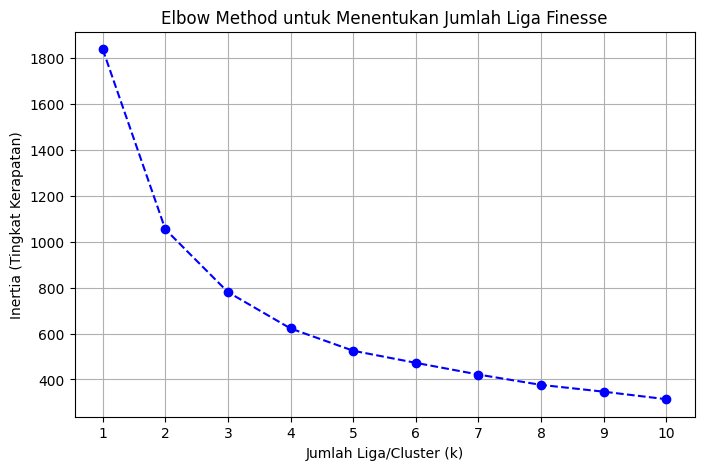

In [ ]:
# Menyamakan skala agar 'total_spent' (jutaan) tidak mendominasi 'transaction_count' (satuan)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow Method
inertia = []
K_range = range(1, 11) # Mencari kemungkinan 1 hingga 10 Liga

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisasi Grafik Elbow
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='--', color='b')
plt.title('Elbow Method untuk Menentukan Jumlah Liga Finesse')
plt.xlabel('Jumlah Liga/Cluster (k)')
plt.ylabel('Inertia (Tingkat Kerapatan)')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
# 1. Gunain 4 cluster dari hasil elbow method tuk Leaderboard
kmeans_final = KMeans(n_clusters=4, random_state=42)
user_data['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Menganalisis Karakteristik Setiap Cluster (Leaderboard)
# Kita hitung rata-rata pengeluaran, frekuensi, dan penggunaan budget dari tiap kelompok
cluster_analysis = user_data.groupby('Cluster').agg({
    'user_id': 'count', # Menghitung jumlah user di tiap liga
    'total_spent': 'mean', # Rata-rata uang yang dihabiskan
    'transaction_count': 'mean', # Rata-rata frekuensi transaksi
    'budget_utilization': 'mean' # Rata-rata persentase pemakaian budget
}).rename(columns={'user_id': 'jumlah_user'})

# Format angka agar mudah dibaca
cluster_analysis['total_spent'] = cluster_analysis['total_spent'].apply(lambda x: f"Rp {x:,.0f}")
cluster_analysis['budget_utilization'] = cluster_analysis['budget_utilization'].apply(lambda x: f"{x*100:.1f}%")
cluster_analysis['transaction_count'] = cluster_analysis['transaction_count'].round(1)

print("=== PROFIL 4 CLUSTER/LIGA FINESSE ===")
print(cluster_analysis)

=== PROFIL 4 CLUSTER/LIGA FINESSE ===
         jumlah_user   total_spent  transaction_count budget_utilization
Cluster                                                                 
0                212  Rp 2,227,009               21.1              83.3%
1                165  Rp 3,948,042               30.1             146.1%
2                161  Rp 4,650,988               22.8             174.0%
3                 75  Rp 7,019,573               28.3             312.3%


In [ ]:
from sklearn.metrics import silhouette_score

# Menghitung Silhouette Score untuk 4 Leaderboard kita
sil_score = silhouette_score(X_scaled, user_data['Cluster'])
print(f"Silhouette Score (k=4): {sil_score:.3f}")

Silhouette Score (k=4): 0.327


In [ ]:
import joblib
joblib.dump(scaler, 'scaler_finesse.pkl') # scaler agar data transaksi user baru di web nanti punya skala hitungan yang sama
joblib.dump(kmeans_final, 'kmeans_finesse.pkl') # model K-Means yang sudah dilatih

['kmeans_finesse.pkl']